In [60]:
import numpy as np

%load_ext autoreload
%autoreload 2

from pycamcal.primitives.pose import Pose3D, R3D
from pycamcal.primitives.math_helpers import get_random_rotation

from pycamcal.camera_model.camera_model import CameraModel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
camera_model = CameraModel.from_fov((800, 600), (80, 60), distortion=None, degrees=True)

world_points_all = np.random.uniform(low=(-10, -10, -10), high=(+10, +10, +10), size=(100, 3))

camera_pose = Pose3D(
    t=[0, 0, 0], # np.random.normal(loc=(0,0,0), scale=3),
    R=R3D.identity() # get_random_rotation(np.random.uniform(0, 2*np.pi))
)


In [62]:
# visualize scene

import open3d

from pycamcal.simulation.viz_utils import visualize_camera_positioning

visualize_camera_positioning(
    [open3d.geometry.PointCloud(open3d.utility.Vector3dVector(world_points_all))],
    camera_model, [camera_pose]
)

/home/russell.schwartz/Desktop/misc/PyCamCal/pycamcal/primitives/pose.py:33: UserWarning: Explicitly requested dtype float64 requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  jnp.array([[0., 0., 0., 1.]], dtype=jnp.float64)


(600.0, 0.0)

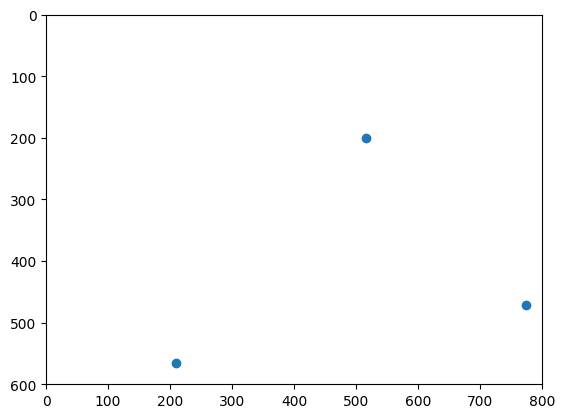

In [63]:
# simulate camera capture

from matplotlib import pyplot as plt

np.set_printoptions(suppress=True)

points_external = camera_pose.inv().apply(world_points_all)
image_points = camera_model.project_into_image(points_external)

# include only those points which are in front of the camera and in frame
mask_in_front = points_external[:,2] > 0
mask_in_frame = np.all((image_points > 0) & (image_points <= camera_model.res_xy), axis=-1)

mask = mask_in_front & mask_in_frame
image_points = image_points[mask]
world_points = world_points_all[mask]

plt.scatter(*image_points[:3].T)
plt.xlim(0, camera_model.res_xy[0])
plt.ylim(camera_model.res_xy[1], 0)

In [64]:
# inverse projection sanity check
rays_local = camera_model.cast_ray_from_pixel(image_points)
rays_world = camera_pose.R.apply(rays_local)

rays_world_true = world_points - camera_pose.t

for i in range(3):
    print(rays_world[i])
    print(rays_world_true[i] / np.linalg.norm(rays_world_true[i]))

[-0.33640662  0.42742193  0.83913106]
[-0.33640662  0.4274219   0.8391311 ]
[ 0.23088741 -0.1843137   0.9553636 ]
[ 0.23088744 -0.18431368  0.9553635 ]
[0.5980902  0.25099173 0.7611119 ]
[0.5980902 0.2509917 0.7611119]


In [65]:
visualize_camera_positioning(
    [open3d.geometry.PointCloud(open3d.utility.Vector3dVector(world_points[:3]))],
    camera_model, [camera_pose]
)

In [66]:
print(world_points[:3])
print(image_points[:3])

[[-2.29732594  2.91887042  5.73043864]
 [ 2.40076728 -1.91649346  9.93386809]
 [ 4.06061993  1.70406058  5.16742495]]
[[208.89096 564.6725 ]
 [515.2068  199.75314]
 [774.5973  471.3534 ]]


a, b, c: 6.2114815079968215 6.497401248226493 7.944913018325633
alpha beta gamma (deg): [35.018295 56.99238  49.817562]
roots: [-0.68797641+1.51622597j -0.68797641-1.51622597j  0.76066507+0.j
 -0.47421328+0.j        ]
ranges: 14.131326846786708 10.749206740303707 13.8106275905235
error: 311.055
[0 0 0]
[-1.3114414 -9.502082   3.323528 ]


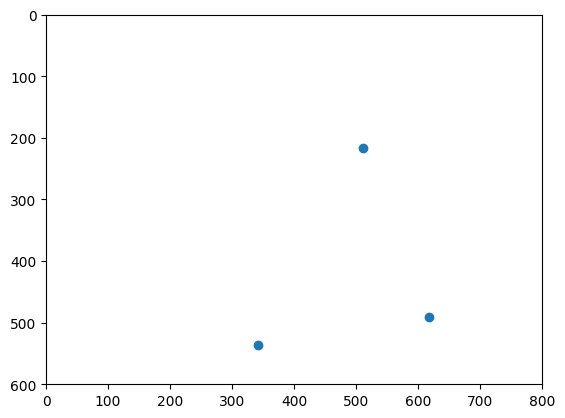

In [67]:
from pycamcal.calibration.pnp import solve_PnP, solve_P3P

# solve_PnP(world_points, image_points, camera_model)


solution = solve_P3P(world_points[:3], image_points[:3], camera_model)

print(camera_pose.t)
print(solution.t)

In [68]:
import cv2

num_solutions, rvecs, tvecs = cv2.solveP3P(
    np.array(world_points[:3]), np.array(image_points[:3]),
    np.array(camera_model.get_intrinsics_matrix()), None,
    cv2.SOLVEPNP_P3P
)

solutions_opencv = [
    Pose3D(t, R3D.from_rotvec(r))
    for t, r in zip(tvecs, rvecs)
]

for solution in solutions_opencv:
    print(solution.t)
    print(solution.R.as_euler("xyz"))
    print()

[ 0.00000213  0.00000033 -0.00000019]
[ 0. -0.  0.]



In [69]:
visualize_camera_positioning(
    [open3d.geometry.PointCloud(open3d.utility.Vector3dVector(world_points[:3]))],
    camera_model, [camera_pose, *solutions_opencv]
)

In [70]:
# true ranges:
np.linalg.norm(world_points[:3] - camera_pose.t, axis=-1)

array([ 6.829015 , 10.397999 ,  6.7893105], dtype=float32)